# Exposure Fusion - Implementazione pulita

Questo notebook implementa l'algoritmo del paper **Exposure Fusion** di Mertens, Kautz e Van Reeth. Mantiene la struttura corretta gia usata in `sample.ipynb` per i pesi percettivi, ma rimuove le celle esplorative e costruisce esplicitamente la piramide di Laplace come differenza tra livelli gaussiani, in modo coerente con la formulazione del paper e con l'articolo IPOL.

## 1. Setup e caricamento immagini

Le immagini sono trattate come array `float64` in `[0, 1]`. Per default viene usata la sequenza `images/venice_carnival/A.jpg`, `B.jpg`, `C.jpg`, che ha dimensioni coerenti con il risultato di riferimento.

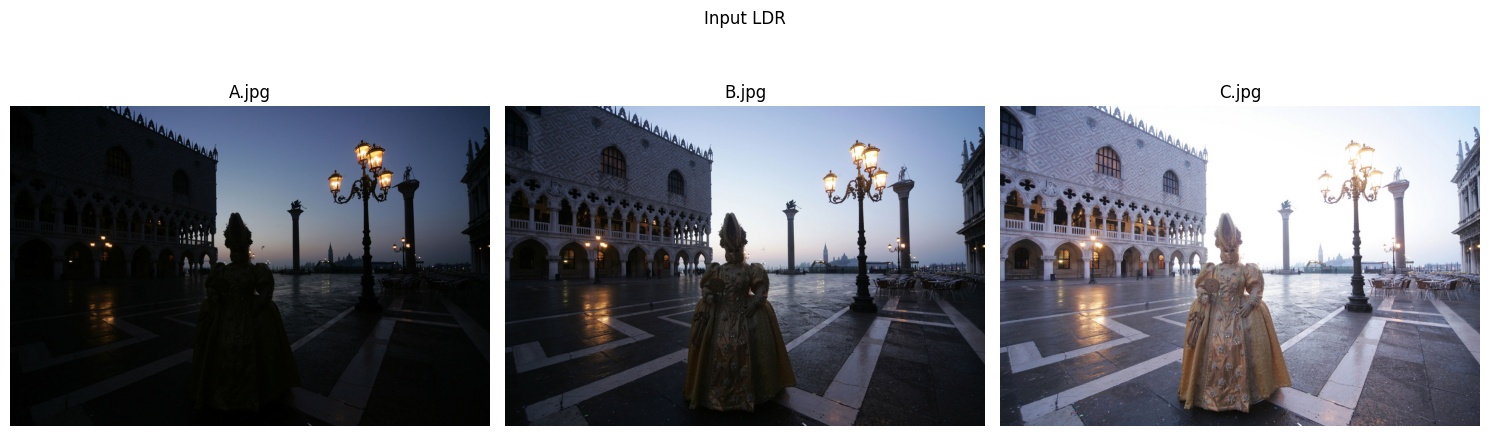

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy.ndimage import convolve
from skimage import exposure, img_as_float
from skimage.color import rgb2gray
from skimage.transform import pyramid_expand, pyramid_gaussian

DIR_PATH = Path("images/venice_carnival")
INPUT_FILES = ["A.jpg", "B.jpg", "C.jpg"]
REFERENCE_FILE = "result.jpg"
OUTPUT_FILE = DIR_PATH / "fused_clean.jpg"

DOWNSCALE = 2
SIGMA_EXPOSEDNESS = 0.2
OMEGA_CONTRAST = 1.0
OMEGA_SATURATION = 1.0
OMEGA_EXPOSEDNESS = 1.0
EPS = 1e-12


def load_rgb_float(path: Path) -> np.ndarray:
    return img_as_float(np.array(Image.open(path).convert("RGB")))


images = [load_rgb_float(DIR_PATH / name) for name in INPUT_FILES]
reference = load_rgb_float(DIR_PATH / REFERENCE_FILE)

shape = images[0].shape
assert all(img.shape == shape for img in images), "All input images must have the same shape."

fig, axes = plt.subplots(1, len(images), figsize=(15, 5))
for ax, img, name in zip(axes, images, INPUT_FILES):
    ax.imshow(img)
    ax.set_title(name)
    ax.axis("off")
plt.suptitle("Input LDR")
plt.tight_layout()
plt.show()

## 2. Metriche di qualita e mappe dei pesi

Per ogni pixel vengono calcolate le tre metriche del paper: contrasto, saturazione e well-exposedness. I pesi sono il prodotto delle tre metriche, eventualmente modulate dagli esponenti `OMEGA_*`.

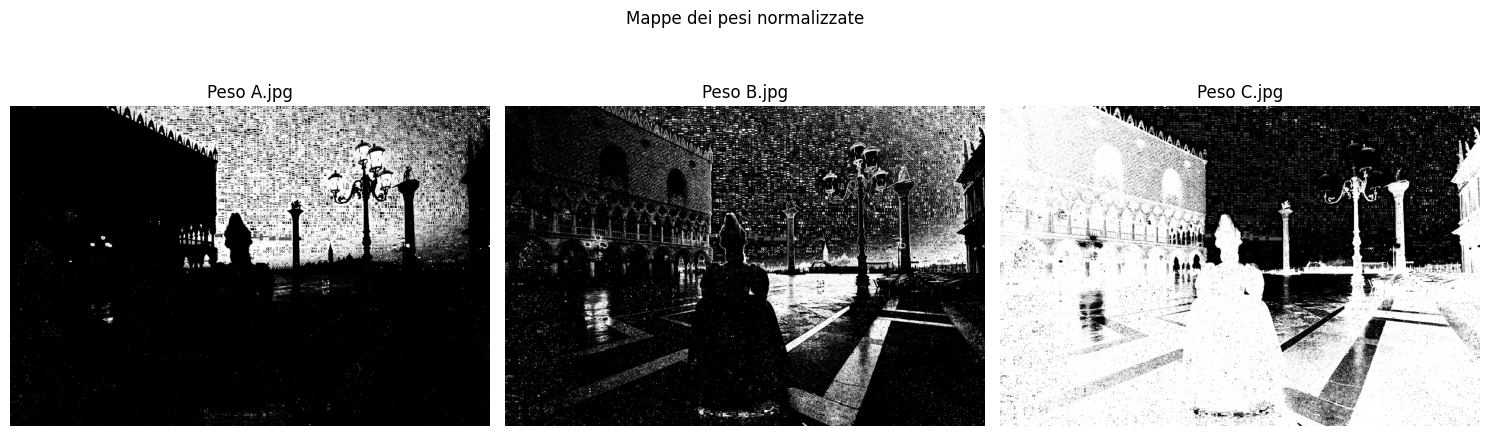

Max deviation from per-pixel weight sum = 3.3306690738754696e-16


In [2]:
LAPLACIAN_KERNEL = np.array(
    [[0.0, 1.0, 0.0],
     [1.0, -4.0, 1.0],
     [0.0, 1.0, 0.0]]
)


def exposedness_curve(values: np.ndarray, sigma: float = SIGMA_EXPOSEDNESS) -> np.ndarray:
    return np.exp(-((values - 0.5) ** 2) / (2 * sigma**2))


def quality_measures(image: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    gray = rgb2gray(image)
    contrast = np.abs(convolve(gray, LAPLACIAN_KERNEL, mode="reflect"))
    saturation = np.std(image, axis=2)
    well_exposedness = np.prod(exposedness_curve(image), axis=2)
    return contrast, saturation, well_exposedness


def weight_map(image: np.ndarray) -> np.ndarray:
    contrast, saturation, well_exposedness = quality_measures(image)
    return (
        contrast**OMEGA_CONTRAST
        * saturation**OMEGA_SATURATION
        * well_exposedness**OMEGA_EXPOSEDNESS
    )


def normalize_weights(weights: np.ndarray) -> np.ndarray:
    weight_sum = weights.sum(axis=0, keepdims=True)
    uniform = np.full_like(weights, 1.0 / weights.shape[0])
    return np.divide(weights, weight_sum, out=uniform, where=weight_sum > EPS)


weights = np.stack([weight_map(img) for img in images])
normalized_weights = normalize_weights(weights)

fig, axes = plt.subplots(1, len(images), figsize=(15, 5))
for ax, w, name in zip(axes, normalized_weights, INPUT_FILES):
    ax.imshow(w, cmap="gray")
    ax.set_title(f"Peso {name}")
    ax.axis("off")
plt.suptitle("Mappe dei pesi normalizzate")
plt.tight_layout()
plt.show()

print("Max deviation from per-pixel weight sum =", np.abs(normalized_weights.sum(axis=0) - 1).max())

## 3. Piramidi gaussiane e laplaciane

La piramide laplaciana viene costruita manualmente a partire dalla piramide gaussiana: ogni livello e la differenza tra il livello gaussiano corrente e l'espansione del livello successivo. L'ultimo livello e il residuo gaussiano. Questa forma e collassabile senza perdere la struttura originale dell'immagine.

In [3]:
def build_gaussian_pyramid(
    image: np.ndarray,
    *,
    max_layer: int = -1,
    channel_axis: int | None = None,
) -> list[np.ndarray]:
    return list(
        pyramid_gaussian(
            image,
            max_layer=max_layer,
            downscale=DOWNSCALE,
            preserve_range=True,
            channel_axis=channel_axis,
        )
    )


def crop_like(image: np.ndarray, reference_shape: tuple[int, ...]) -> np.ndarray:
    slices = tuple(slice(0, size) for size in reference_shape)
    return image[slices]


def build_laplacian_pyramid(image: np.ndarray) -> list[np.ndarray]:
    gaussian_levels = build_gaussian_pyramid(image, channel_axis=-1)
    laplacian_levels = []

    for level in range(len(gaussian_levels) - 1):
        expanded = pyramid_expand(
            gaussian_levels[level + 1],
            upscale=DOWNSCALE,
            preserve_range=True,
            channel_axis=-1,
        )
        expanded = crop_like(expanded, gaussian_levels[level].shape)
        laplacian_levels.append(gaussian_levels[level] - expanded)

    laplacian_levels.append(gaussian_levels[-1])
    return laplacian_levels


def collapse_laplacian_pyramid(laplacian_levels: list[np.ndarray]) -> np.ndarray:
    image = laplacian_levels[-1]

    for level in reversed(laplacian_levels[:-1]):
        image = pyramid_expand(
            image,
            upscale=DOWNSCALE,
            preserve_range=True,
            channel_axis=-1,
        )
        image = crop_like(image, level.shape)
        image = image + level

    return image


# Sanity check interno: una piramide laplaciana corretta deve ricostruire l'input.
reconstructed = collapse_laplacian_pyramid(build_laplacian_pyramid(images[0]))
assert np.mean((reconstructed - images[0]) ** 2) < 1e-24

image_laplacian_pyramids = [build_laplacian_pyramid(img) for img in images]
num_levels = len(image_laplacian_pyramids[0])

weight_gaussian_pyramids = [
    build_gaussian_pyramid(w, max_layer=num_levels - 1, channel_axis=None)
    for w in normalized_weights
]

print(f"Pyramid levels: {num_levels}")
print("Level shapes:", [level.shape for level in image_laplacian_pyramids[0]])

Pyramid levels: 12
Level shapes: [(800, 1200, 3), (400, 600, 3), (200, 300, 3), (100, 150, 3), (50, 75, 3), (25, 38, 3), (13, 19, 3), (7, 10, 3), (4, 5, 3), (2, 3, 3), (1, 2, 3), (1, 1, 3)]


## 4. Fusione multi-scala

Ogni livello della piramide laplaciana del risultato e una media pesata dei corrispondenti livelli laplaciani delle immagini sorgenti. I pesi usati a quel livello provengono dalla piramide gaussiana delle mappe dei pesi normalizzate.

In [4]:
# Rinormalizzazione prudente dei pesi a ogni scala.
for level in range(num_levels):
    level_weights = np.stack([pyramid[level] for pyramid in weight_gaussian_pyramids])
    normalized_level_weights = normalize_weights(level_weights)
    for image_index, pyramid in enumerate(weight_gaussian_pyramids):
        pyramid[level] = normalized_level_weights[image_index]

fused_laplacian_pyramid = []
for level in range(num_levels):
    fused_level = np.zeros_like(image_laplacian_pyramids[0][level])

    for image_index in range(len(images)):
        weights_at_level = weight_gaussian_pyramids[image_index][level][..., np.newaxis]
        fused_level += weights_at_level * image_laplacian_pyramids[image_index][level]

    fused_laplacian_pyramid.append(fused_level)

fused_raw = collapse_laplacian_pyramid(fused_laplacian_pyramid)
print("Raw fused range:", fused_raw.min(), fused_raw.max())
print("Out-of-range pixels:", np.mean(fused_raw < 0), np.mean(fused_raw > 1))

Raw fused range: -0.1738339778013635 1.4268000997194088
Out-of-range pixels: 0.024861458333333333 0.012524305555555556


## 5. Output finale

Il collasso della piramide puo produrre valori leggermente fuori da `[0, 1]`, come discusso anche nell'articolo IPOL. Qui viene mostrato il risultato con clipping semplice, mantenendo separata ogni eventuale correzione estetica.

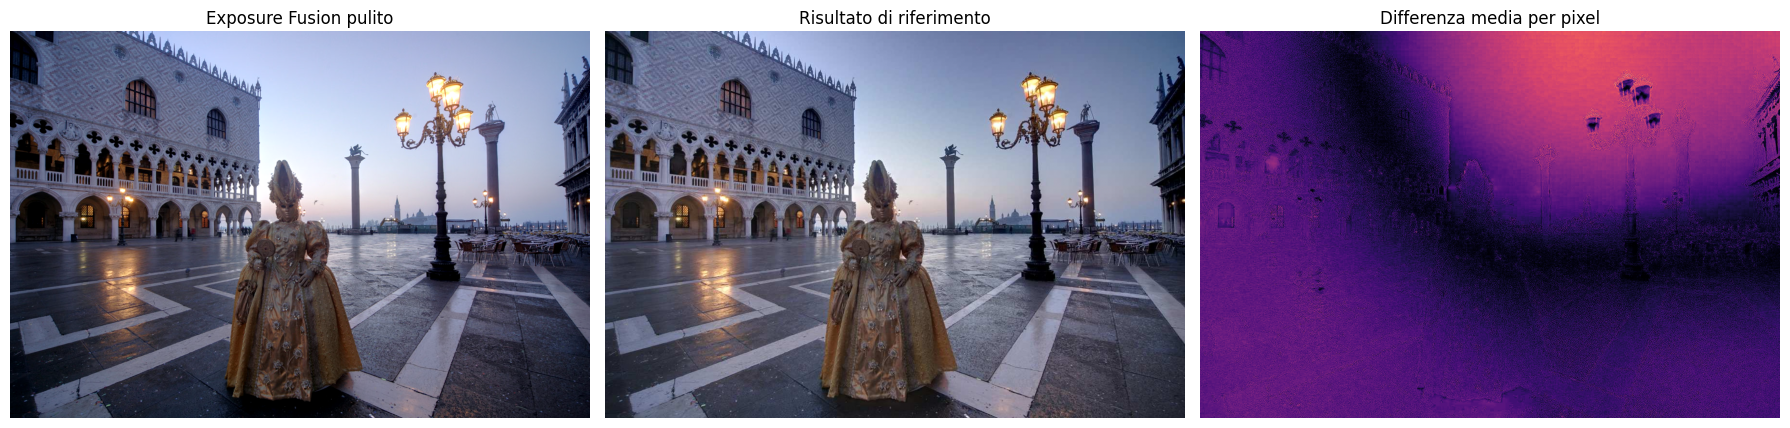

Saved: images/venice_carnival/fused_clean.jpg


In [5]:
fused_clipped = np.clip(fused_raw, 0, 1)
Image.fromarray((fused_clipped * 255).astype(np.uint8)).save(OUTPUT_FILE)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(fused_clipped)
axes[0].set_title("Exposure Fusion pulito")
axes[0].axis("off")

axes[1].imshow(reference)
axes[1].set_title("Risultato di riferimento")
axes[1].axis("off")

axes[2].imshow(np.abs(fused_clipped - reference).mean(axis=2), cmap="magma")
axes[2].set_title("Differenza media per pixel")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print(f"Saved: {OUTPUT_FILE}")

## Nota finale

Questa versione implementa il nucleo dell'algoritmo senza post-processing aggressivo. Per esperimenti successivi si puo aggiungere una normalizzazione robusta dell'output, come suggerito da `article_lr.pdf`, ma dovrebbe restare uno step separato dalla fusione multi-scala.